# 1.Enivronment Setup

In [1]:
import torch
import torchvision
import timm

print("=" * 50)
print("ENVIRONMENT CHECK")
print("=" * 50)

print("PyTorch       :", torch.__version__)
print("Torchvision   :", torchvision.__version__)
print("timm          :", timm.__version__)
print("CUDA available:", torch.cuda.is_available())
print("PyTorch CUDA  :", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU           :", torch.cuda.get_device_name(0))

print("=" * 50)

Y:\Python\AI ML\Month 2\week 7-Deep Learning\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ENVIRONMENT CHECK
PyTorch       : 2.7.1+cu128
Torchvision   : 0.22.1+cu128
timm          : 1.0.30
CUDA available: True
PyTorch CUDA  : 12.8
GPU           : NVIDIA GeForce GTX 1650


# 2.  CIFAR-10 dataset setup

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

from torch.utils.data import DataLoader

In [3]:
train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True
)

In [4]:
print('Training dataset: ',len(train_dataset))
print('Test dataset: ',len(test_dataset))

Training dataset:  50000
Test dataset:  10000


In [5]:
# this will return the classes available in cifar 10 dataset and position assingned to it
print(train_dataset.classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [6]:
# to inspect the one image 
image,label = train_dataset[0]

print(type(image))
print(image.size) # this will return the size in pixel
print(label)
print(train_dataset.classes[label])

<class 'PIL.Image.Image'>
(32, 32)
6
frog


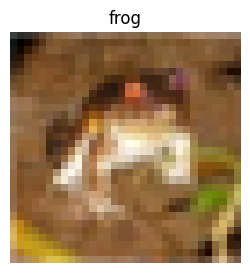

In [7]:
# to visualize the image 

plt.figure(figsize=(3,3))

plt.imshow(image)
plt.title(train_dataset.classes[label])
plt.axis('off')

plt.show()

In [8]:
# understanding the raw image representation 

image_np = np.array(image)

print("NumPy shape:", image_np.shape)
print("Data type:", image_np.dtype)
print("Minimum pixel value:", image_np.min())
print("Maximum pixel value:", image_np.max())

NumPy shape: (32, 32, 3)
Data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255


In [9]:
# to transform the image to tensors so that we can process it 

transform = transforms.ToTensor()

In [10]:
# Recreate the datasets with the transform

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

In [11]:
# inspecting the images again 
# now its tensor converted so now(3,32,32)
# and pixel values ranges from 0-1 instead of 0-225 

image, label = train_dataset[0]

print("Image type :", type(image))
print("Image shape:", image.shape)
print("Data type  :", image.dtype)
print("Min value  :", image.min())
print("Max value  :", image.max())
print("Label      :", label)

Image type : <class 'torch.Tensor'>
Image shape: torch.Size([3, 32, 32])
Data type  : torch.float32
Min value  : tensor(0.)
Max value  : tensor(1.)
Label      : 6


In [12]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [13]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([64, 3, 32, 32])
Labels shape: torch.Size([64])


In [14]:
# moving the batch to GPU cuda 

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

In [15]:
images = images.to(device)
labels = labels.to(device)

print("Images device:", images.device)
print("Labels device:", labels.device)

Images device: cuda:0
Labels device: cuda:0


In [16]:
# now lets visualize the entire batch 

images,labels = next(iter(train_loader))

In [17]:
# for plotting we temporarily move to the CPU 

images_cpu = images.cpu()
labels_cpu = labels.cpu()

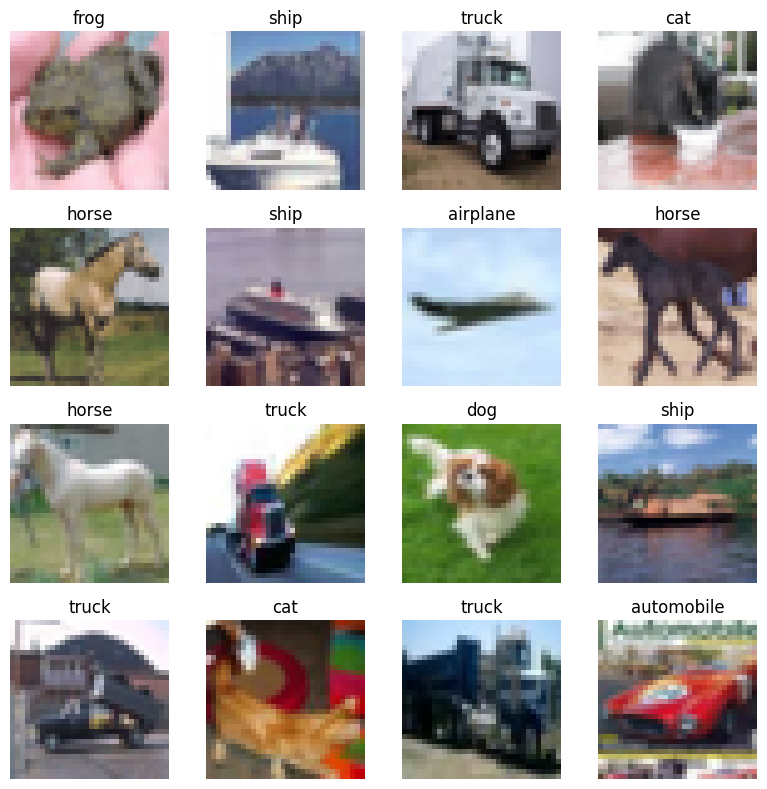

In [18]:
fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    image = images_cpu[i].permute(1, 2, 0)

    ax.imshow(image)
    ax.set_title(train_dataset.classes[labels_cpu[i].item()])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [19]:
# check the labels 

print(labels_cpu[:16])

tensor([6, 8, 9, 3, 7, 8, 0, 7, 7, 9, 5, 8, 9, 3, 9, 1])


In [20]:
# check the classes distribution 

from collections import Counter

train_labels = [label for _, label in train_dataset]

class_counts = Counter(train_labels)

for class_id, count in sorted(class_counts.items()):
    print(
        class_id,
        "→",
        train_dataset.classes[class_id],
        ":",
        count
    )

0 → airplane : 5000
1 → automobile : 5000
2 → bird : 5000
3 → cat : 5000
4 → deer : 5000
5 → dog : 5000
6 → frog : 5000
7 → horse : 5000
8 → ship : 5000
9 → truck : 5000


In [21]:
test_labels = [label for _, label in test_dataset]

test_counts = Counter(test_labels)

for class_id, count in sorted(test_counts.items()):
    print(
        class_id,
        "→",
        test_dataset.classes[class_id],
        ":",
        count
    )

0 → airplane : 1000
1 → automobile : 1000
2 → bird : 1000
3 → cat : 1000
4 → deer : 1000
5 → dog : 1000
6 → frog : 1000
7 → horse : 1000
8 → ship : 1000
9 → truck : 1000


# 3.Pretrained ViT

In [22]:
# list out the models 
import timm

vit_models = timm.list_models("*vit*")

print("Number of ViT models:", len(vit_models))

for model_name in vit_models[:20]:
    print(model_name)

Number of ViT models: 400
convit_base
convit_small
convit_tiny
crossvit_9_240
crossvit_9_dagger_240
crossvit_15_240
crossvit_15_dagger_240
crossvit_15_dagger_408
crossvit_18_240
crossvit_18_dagger_240
crossvit_18_dagger_408
crossvit_base_240
crossvit_small_240
crossvit_tiny_240
davit_base
davit_base_fl
davit_giant
davit_huge
davit_huge_fl
davit_large


In [23]:
# lets choose the vit_base_patch16_224 our model with pretrained values 
model = timm.create_model(
    "vit_base_patch16_224",
    pretrained=True
)

In [24]:
model = model.to(device)

print("Model device:", next(model.parameters()).device)

Model device: cuda:0


In [25]:
model.eval()

print("Model is ready for inference.")

Model is ready for inference.


In [26]:
# inspectingg the model 
print("Model type:", type(model).__name__)
print("Number of classes:", model.num_classes)
print("Embedding dimension:", model.embed_dim)
print("Patch size:", model.patch_embed.patch_size)
print("Number of transformer blocks:", len(model.blocks))

# the ViT has 1000 classes but our CIFAR10 has only 10 classes 
# so we cannot directly apply the model(images)

Model type: VisionTransformer
Number of classes: 1000
Embedding dimension: 768
Patch size: (16, 16)
Number of transformer blocks: 12


```
Prepare a CIFAR-10 Image for ViT

This is our next step.

We'll take:

CIFAR-10
32 × 32 × 3

and construct the preprocessing pipeline expected by the pretrained ViT:

CIFAR-10 image
       ↓
Resize
       ↓
224 × 224
       ↓
Convert to Tensor
       ↓
Normalize
       ↓
Add batch dimension
       ↓
[1, 3, 224, 224]
       ↓
ViT

```

In [27]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 86567656
Trainable parameters: 86567656


In [28]:
# inspect the pretrained model's expected preprocessing
data_config = timm.data.resolve_model_data_config(model)

print(data_config)

{'input_size': (3, 224, 224), 'interpolation': 'bicubic', 'mean': (0.5, 0.5, 0.5), 'std': (0.5, 0.5, 0.5), 'crop_pct': 0.9, 'crop_mode': 'center'}


In [29]:
transform = timm.data.create_transform(**data_config, is_training=False)

print(transform)

# so first we have to resize from 32 * 32 to 248*248(using the bicubic transformation)
# then using the centrecrop we resizing to 224 * 224 
# then these images are converted to tensor if its necessary
# actual pixel values are varies from 0-255 then after transfrom 0-1 after final transfrmation its normalize around -1 - +1


Compose(
    Resize(size=248, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    MaybeToTensor()
    Normalize(mean=tensor([0.5000, 0.5000, 0.5000]), std=tensor([0.5000, 0.5000, 0.5000]))
)


In [30]:
# now lets take a raw cifar image 
raw_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=False
)

image, label = raw_dataset[0]

print("Original image:")
print("Type :", type(image))
print("Size :", image.size)
print("Class:", raw_dataset.classes[label])

Original image:
Type : <class 'PIL.Image.Image'>
Size : (32, 32)
Class: frog


In [31]:
# lets apply the vit ttransform

vit_input = transform(image)

print("After ViT preprocessing:")
print("Shape :", vit_input.shape)
print("Dtype :", vit_input.dtype)
print("Min   :", vit_input.min().item())
print("Max   :", vit_input.max().item())

# look now the values are normalized between the -1 and +1 
# and image is also resized 3,224,224 



After ViT preprocessing:
Shape : torch.Size([3, 224, 224])
Dtype : torch.float32
Min   : -1.0
Max   : 1.0


In [32]:
# to add the batch dimension 
vit_input = vit_input.unsqueeze(0)

print("Final input shape:", vit_input.shape)

Final input shape: torch.Size([1, 3, 224, 224])


In [33]:
# checking the input device 

vit_input = vit_input.to(device)

print("Device:", vit_input.device)

Device: cuda:0


In [34]:
#  run the forward pass 

with torch.no_grad():
     output = model(vit_input)

print(output.shape)

# 1000 coz the original ViT classes are 1000 

torch.Size([1, 1000])


In [35]:
print(output[0][:10])

tensor([ 0.4918,  0.2965, -0.2864, -1.1704, -1.9205,  1.3803, -1.3594, -1.0261,
         0.1941, -1.0189], device='cuda:0')


In [36]:
# to convert the logits to probabilites

probabilities = torch.softmax(output,dim=1)
print(probabilities.shape)
print(probabilities.sum().item())

torch.Size([1, 1000])
0.9999998807907104


In [37]:
predicted_idx = output.argmax(dim=1)

print("Predicted ImageNet class index:", predicted_idx.item())

Predicted ImageNet class index: 32


In [38]:
predicted_probability = probabilities[
    0,
    predicted_idx.item()
]

print(
    "Predicted class index:",
    predicted_idx.item()
)

print(
    "Probability:",
    predicted_probability.item()
)

Predicted class index: 32
Probability: 0.2828371822834015


In [39]:
# inspect the model 

print(model.head)

Linear(in_features=768, out_features=1000, bias=True)


In [40]:
# our actual classes is 10 so we changing it  

model.head = torch.nn.Linear(
    in_features= model.head.in_features,
    out_features=10
)

In [41]:
print(model.head)

Linear(in_features=768, out_features=10, bias=True)


In [42]:
# Freeze the ViT backbone
for param in model.parameters():
    param.requires_grad = False

# Unfreeze only the new classification head
for param in model.head.parameters():
    param.requires_grad = True

In [43]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print("Total parameters     :", total_params)
print("Trainable parameters :", trainable_params)

Total parameters     : 85806346
Trainable parameters : 7690


In [44]:
# Create the ViT-specific CIFAR-10 DataLoader

# lets create the ViT transform 

vit_train_transform = timm.data.create_transform(
    **data_config,
    is_training=True
)

vit_test_transform = timm.data.create_transform(
    **data_config,
    is_training=False
)

# Reason for 2 transformation is we use augmentation in the training data so it model dont memorize the training data it could generalize well 

In [45]:
# create the cifar 10 dataset for the ViT 

vit_train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=False,
    transform=vit_train_transform
)

vit_test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=False,
    transform=vit_test_transform
)

In [46]:
# creating the dataloaders 

vit_train_loader = torch.utils.data.DataLoader(
    vit_train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

vit_test_loader = torch.utils.data.DataLoader(
    vit_test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [47]:
# lets check one batch 

images,labels = next(iter(vit_train_loader))

print(images.shape, ' ',labels.shape)
print(images.dtype, ' ',labels.dtype)
print(images.device, ' ',labels.device)

# the DataDataLoader preferes the CPU 
# thats why here shown the cpu 
# we can change them during the training CPU - CUDA

torch.Size([32, 3, 224, 224])   torch.Size([32])
torch.float32   torch.int64
cpu   cpu


In [48]:
# loss function 

criterion = torch.nn.CrossEntropyLoss()

In [49]:
# Optimizer

optimizer = torch.optim.AdamW(
    model.head.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

In [50]:
print("Loss function :", criterion)
print("Optimizer     :", optimizer)

Loss function : CrossEntropyLoss()
Optimizer     : AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)


In [51]:
# lets do one manual training batch 

# change the labels from cpu to cuda 
images, labels = next(iter(vit_train_loader))

images = images.to(device)
labels = labels.to(device)

print("Images:", images.shape, images.device)
print("Labels:", labels.shape, labels.device)

Images: torch.Size([32, 3, 224, 224]) cuda:0
Labels: torch.Size([32]) cuda:0


In [52]:
model.head = model.head.to(device)
print("Model device:", next(model.parameters()).device)
print("Head device :", model.head.weight.device)
print("Image device:", images.device)

Model device: cuda:0
Head device : cuda:0
Image device: cuda:0


In [53]:
model.train() # put the model in training mode

optimizer.zero_grad() #clear out the old gradients 

In [54]:
# Forward pass
outputs = model(images)
print("Output shape:", outputs.shape)
# Now output is 10 coz coz we changed it in the model 

Output shape: torch.Size([32, 10])


In [55]:
# calculate the loss 
loss = criterion(outputs, labels)

print("Loss:", loss.item())

Loss: 2.489683151245117


In [56]:
# backpropogation and find out the gradient value 
loss.backward()

print(
    "Head gradient mean:",
    model.head.weight.grad.abs().mean().item()
)

Head gradient mean: 0.06471599638462067


In [57]:
# to update the weights 
optimizer.step()

In [58]:
import sys
from tqdm import tqdm

num_epochs = 1

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(
        vit_train_loader,
        total=len(vit_train_loader),
        desc=f"Epoch {epoch+1}/{num_epochs}",
        unit="batch",
        file=sys.stdout,
        dynamic_ncols=True,
        mininterval=1
    )

    for batch_idx, (images, labels) in enumerate(progress_bar):

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Loss
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

        # Current metrics
        current_loss = running_loss / total
        current_accuracy = 100 * correct / total

        progress_bar.set_postfix(
            loss=f"{current_loss:.4f}",
            accuracy=f"{current_accuracy:.2f}%"
        )

    progress_bar.close()

    print(
        f"Epoch {epoch+1}/{num_epochs} completed | "
        f"Loss: {current_loss:.4f} | "
        f"Accuracy: {current_accuracy:.2f}%"
    )

Epoch 1/1: 100%|██████████| 1563/1563 [19:23<00:00,  1.34batch/s, accuracy=87.59%, loss=0.3849]
Epoch 1/1 completed | Loss: 0.3849 | Accuracy: 87.59%


In [59]:
test_loss = 0.0
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in vit_test_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Statistics
        test_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

test_loss = test_loss / total
test_accuracy = 100 * correct / total

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.2f}%")

Test Loss     : 0.0904
Test Accuracy : 97.23%


# 4. Fine Tuning

In [60]:
# now lets import fresh pretrained ViT

import torch
import timm

# Fresh pretrained ViT
model = timm.create_model(
    "vit_base_patch16_224",
    pretrained=True
)

# Replace ImageNet classifier with CIFAR-10 classifier
model.head = torch.nn.Linear(
    model.head.in_features,
    10
)

# Move complete model to GPU
model = model.to(device)

print(model.head)

Linear(in_features=768, out_features=10, bias=True)


In [61]:
# freezing everything

for param in model.parameters():
    param.requires_grad = False

In [62]:
model.blocks

Sequential(
  (0): Block(
    (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
    (attn): Attention(
      (qkv): Linear(in_features=768, out_features=2304, bias=True)
      (q_norm): Identity()
      (k_norm): Identity()
      (attn_drop): Dropout(p=0.0, inplace=False)
      (norm): Identity()
      (proj): Linear(in_features=768, out_features=768, bias=True)
      (proj_drop): Dropout(p=0.0, inplace=False)
    )
    (ls1): Identity()
    (drop_path1): Identity()
    (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
    (mlp): Mlp(
      (fc1): Linear(in_features=768, out_features=3072, bias=True)
      (act): GELU(approximate='none')
      (drop1): Dropout(p=0.0, inplace=False)
      (norm): Identity()
      (fc2): Linear(in_features=3072, out_features=768, bias=True)
      (drop2): Dropout(p=0.0, inplace=False)
    )
    (ls2): Identity()
    (drop_path2): Identity()
  )
  (1): Block(
    (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
    

In [63]:
# there are 12 blocks 0-11 
# lets unfreeze the last three blocks 

for block in model.blocks[-3:]:
    for param in block.parameters():
        param.requires_grad = True

In [64]:
# and unfreezing the classifier 
for param in model.head.parameters():
    param.requires_grad = True

In [65]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total parameters     :", total_params)
print("Trainable parameters :", trainable_params)

# now we training around like 21 Million alone instead of 85 million parameters 

Total parameters     : 85806346
Trainable parameters : 21271306


In [66]:
criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5,
    weight_decay=1e-4
)

In [67]:
# befoore long run just training the one batch 
model.train()

images, labels = next(iter(vit_train_loader))

images = images.to(device, non_blocking=True)
labels = labels.to(device, non_blocking=True)

optimizer.zero_grad()

outputs = model(images)

loss = criterion(outputs, labels)

loss.backward()

print("Output shape:", outputs.shape)
print("Loss:", loss.item())

optimizer.step()

Output shape: torch.Size([32, 10])
Loss: 2.6158814430236816


In [68]:
import sys
from tqdm import tqdm

num_epochs = 1

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(
        vit_train_loader,
        total=len(vit_train_loader),
        desc=f"Epoch {epoch+1}/{num_epochs}",
        unit="batch",
        file=sys.stdout,
        dynamic_ncols=True,
        mininterval=1
    )

    for images, labels in progress_bar:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

        current_loss = running_loss / total
        current_accuracy = 100 * correct / total

        progress_bar.set_postfix(
            loss=f"{current_loss:.4f}",
            accuracy=f"{current_accuracy:.2f}%"
        )

    progress_bar.close()

    print(
        f"Epoch {epoch+1}/{num_epochs} completed | "
        f"Loss: {current_loss:.4f} | "
        f"Accuracy: {current_accuracy:.2f}%"
    )

Epoch 1/1: 100%|██████████| 1563/1563 [27:05<00:00,  1.04s/batch, accuracy=87.94%, loss=0.3670]
Epoch 1/1 completed | Loss: 0.3670 | Accuracy: 87.94%


In [69]:
model.eval()

test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():

    for images, labels in vit_test_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)

        loss = criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

test_loss = test_loss / total
test_accuracy = 100 * correct / total

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.2f}%")

Test Loss     : 0.0586
Test Accuracy : 98.25%


In [70]:
import time
import os
import torch

# ============================================================
# ViT FINAL BENCHMARK
# ============================================================

model.eval()
model = model.to(device)

# ------------------------------------------------------------
# 1. Parameter count
# ------------------------------------------------------------

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

# ------------------------------------------------------------
# 2. Save model and calculate size
# ------------------------------------------------------------

model_path = "vit_b16_cifar10_final.pth"

torch.save(model.state_dict(), model_path)

model_size_mb = os.path.getsize(model_path) / (1024 ** 2)

# ------------------------------------------------------------
# 3. Warm-up
# ------------------------------------------------------------

with torch.no_grad():
    for images, labels in vit_test_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        _ = model(images)

        break

torch.cuda.synchronize()

# ------------------------------------------------------------
# 4. Inference benchmark
# ------------------------------------------------------------

start_time = time.perf_counter()

total_images = 0

with torch.no_grad():

    for images, labels in vit_test_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        _ = model(images)

        total_images += images.size(0)

torch.cuda.synchronize()

total_time = time.perf_counter() - start_time

# ------------------------------------------------------------
# 5. Metrics
# ------------------------------------------------------------

ms_per_image = (
    total_time / total_images
) * 1000

throughput = (
    total_images / total_time
)

# ------------------------------------------------------------
# 6. Print results
# ------------------------------------------------------------

print("=" * 60)
print("ViT-B/16 — FINAL BENCHMARK")
print("=" * 60)

print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"Model size           : {model_size_mb:.2f} MB")
print(f"Test images          : {total_images:,}")
print(f"Total inference time : {total_time:.4f} sec")
print(f"Time / image         : {ms_per_image:.4f} ms")
print(f"Throughput           : {throughput:.2f} images/sec")

print("=" * 60)

ViT-B/16 — FINAL BENCHMARK
Total parameters     : 85,806,346
Trainable parameters : 21,271,306
Model size           : 327.38 MB
Test images          : 10,000
Total inference time : 236.0979 sec
Time / image         : 23.6098 ms
Throughput           : 42.36 images/sec


| Model                      | Total Params | Trainable Params | Test Accuracy |  Test Loss | Inference / Image |        Throughput |  Model Size |
| -------------------------- | -----------: | ---------------: | ------------: | ---------: | ----------------: | ----------------: | ----------: |
| **ResNet50 — Fine-Tuning** |       23.61M |           14.47M |    **89.04%** |     0.3351 |       **1.53 ms** |      651.77 img/s |   200.86 MB |
| **EfficientNetB0**         |        4.06M |           12.81K |    **84.03%** |     0.4852 |       **0.94 ms** |     1066.32 img/s |    15.50 MB |
| **MobileNetV2**            |        2.27M |           12.81K |    **84.50%** |     0.4412 |       **0.68 ms** | **1471.09 img/s** | **8.88 MB** |
| **ConvNeXtTiny**           |       27.83M |            7.69K |    **86.79%** |     0.3993 |           2.59 ms |      385.36 img/s |   106.36 MB |
| **ViT-B/16 — Fine-Tuning** |   **85.81M** |       **21.27M** |    **98.25%** | **0.0586** |          23.61 ms |       42.36 img/s |   327.38 MB |


| Metric                    | Exp 1 — ResNet50 Full Training | Exp 2 — ResNet50 Feature Extraction | Exp 3 — ResNet50 Fine-Tuning | Exp 4 — EfficientNetB0 | Exp 5 — MobileNetV2 | Exp 6 — ConvNeXtTiny | **Exp 7 — ViT-B/16 Feature Extraction** |        **Exp 8 — ViT-B/16 Fine-Tuning** |
| ------------------------- | -----------------------------: | ----------------------------------: | ---------------------------: | ---------------------: | ------------------: | -------------------: | --------------------------------------: | --------------------------------------: |
| **Backbone**              |                       ResNet50 |                            ResNet50 |                     ResNet50 |         EfficientNetB0 |         MobileNetV2 |         ConvNeXtTiny |                            **ViT-B/16** |                            **ViT-B/16** |
| **Backbone state**        |                Fully trainable |                        Fully frozen |     Last 30 layers trainable |                 Frozen |              Frozen |               Frozen |                        **Fully frozen** | **Last 3 Transformer blocks trainable** |
| **Trainable parameters**  |                     23,555,082 |                              20,490 |                   14,470,666 |                 12,810 |              12,810 |                7,690 |                               **7,690** |                          **21,271,306** |
| **Total parameters**      |                     23,608,202 |                          23,608,202 |                   23,608,202 |              4,062,381 |           2,270,794 |           27,827,818 |                          **85,806,346** |                          **85,806,346** |
| **Test accuracy**         |                         87.47% |                              84.93% |                   **89.04%** |                 84.03% |              84.50% |               86.79% |                              **97.23%** |                              **98.25%** |
| **Test loss**             |                         0.4227 |                              0.4522 |                   **0.3351** |                 0.4852 |              0.4412 |               0.3993 |                              **0.0904** |                              **0.0586** |
| **Inference / 10k**       |                        14.95 s |                             14.80 s |                      15.34 s |                 9.38 s |              6.80 s |              25.95 s |                                       — |                          **236.0979 s** |
| **Time / image**          |                        1.50 ms |                             1.48 ms |                      1.53 ms |                0.94 ms |         **0.68 ms** |              2.59 ms |                                       — |                          **23.6098 ms** |
| **Throughput**            |                   668.83 img/s |                        675.86 img/s |                 651.77 img/s |          1066.32 img/s |   **1471.09 img/s** |         385.36 img/s |                                       — |                         **42.36 img/s** |
| **Storage / weight size** |                     270.57 MB* |                           90.54 MB* |                   200.86 MB* |          **15.50 MB†** |        **8.88 MB†** |           106.36 MB† |                          **327.38 MB†** |                          **327.38 MB†** |